<a href="https://colab.research.google.com/github/Farrukh776/flyrank-ai/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Farrukh776/flyrank-ai/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)



In [1]:
#setup

import os, subprocess, sys
if "google.colab" in sys.modules and not os.path.exists("flyrank-ai"):
    subprocess.run(["git", "clone", "https://github.com/Farrukh776/flyrank-ai.git"], check=True)
if os.path.basename(os.getcwd()) != "flyrank-ai":
    os.chdir("flyrank-ai")

%pip -q install duckdb
import duckdb, pandas as pd, numpy as np, json
from google.colab import userdata

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
REL = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "2026-03"

features = con.sql(f"""
SELECT
  f.content_hash_id, f.client_hash_id,
  SUM(f.gsc_impressions) AS impressions_month,
  SUM(f.gsc_clicks) AS clicks_month,
  SUM(f.gsc_sum_position) / NULLIF(SUM(f.gsc_impressions), 0) AS avg_position,
  DATE '2026-03-31' - ANY_VALUE(d.content_created_date) AS content_age_days,
  ANY_VALUE(d.word_count) AS word_count,
  ANY_VALUE(d.search_volume) AS search_volume,
  ANY_VALUE(d.competition) AS competition
FROM read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/*.parquet') f
LEFT JOIN read_parquet('{REL}/dim_content.parquet') d
  ON f.content_hash_id = d.content_hash_id
GROUP BY f.content_hash_id, f.client_hash_id
""").df()
features["ctr"] = features["clicks_month"] / features["impressions_month"].replace(0, np.nan)

halves = con.sql(f"""
SELECT content_hash_id,
  SUM(CASE WHEN report_date < DATE '2026-03-16' THEN gsc_impressions END) AS impr_h1,
  SUM(CASE WHEN report_date >= DATE '2026-03-16' THEN gsc_impressions END) AS impr_h2
FROM read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/*.parquet')
GROUP BY content_hash_id
""").df()
halves["pct_change"] = (halves["impr_h2"] - halves["impr_h1"]) / halves["impr_h1"].replace(0, pd.NA)
halves["declined"] = (halves["pct_change"] < 0).astype(int)

df = features.merge(halves[["content_hash_id", "declined"]], on="content_hash_id")
df = df.dropna(subset=["avg_position", "ctr"])

feature_cols = ["impressions_month", "avg_position", "ctr", "content_age_days",
                 "word_count", "search_volume", "competition"]

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

X = df[feature_cols].fillna(0)
y = df["declined"]
groups = df["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
rf.fit(X.iloc[train_idx], y.iloc[train_idx])

df["model_score"] = rf.predict_proba(X)[:, 1]
print("Model rebuilt. Base rate:", round(y.mean(), 3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model rebuilt. Base rate: 0.377


## 1. Ranked actions + reason codes

**Archetype → action mapping:**

| Archetype | Reason code | Action | Why |
|---|---|---|---|
| Ranks well, low CTR | `ranks_ok_but_low_ctr` | `fix_ctr_snippet` | Confirmed in Week 4/paper Finding #3: CTR falls sharply as position worsens — but a page already ranking well with low CTR is a snippet/title problem, not a ranking problem |
| Old + still visible | `old_but_visible` | `review_for_refresh` | Week 4 baseline signal — weak alone (age was OPPOSITE/MIXED for decline in Week 4), but combined with visibility still flags real review candidates |
| Model flags high risk | `model_flagged_high_risk` | `review_for_refresh` | Random Forest score ≥0.7, from the validated model in Week 5/6 (precision@50 = 0.66 on a grouped holdout) |
| Everything else | `monitor` | `no_action` | No confirmed signal fires — not enough evidence to prioritize |

**Decay/refresh insight:** per the paper's Finding #8 (Age-Freshness Matrix), old content that gets refreshed performs nearly as well as young fresh content (44.6 vs 44.1 health) — refresh timing, not age alone, is the lever worth acting on.

In [2]:
def reason_code(row):
    if row["ctr"] < 0.0035 and row["avg_position"] <= 20:
        return "ranks_ok_but_low_ctr"          # matches paper Finding #3 (CTR by position tier)
    if row["content_age_days"] >= 365 and row["impressions_month"] >= 500:
        return "old_but_visible"                # matches Week 4 baseline logic
    if row["model_score"] >= 0.7:
        return "model_flagged_high_risk"
    return "monitor"

def action_label(row):
    rc = row["reason_code"]
    if rc == "ranks_ok_but_low_ctr": return "fix_ctr_snippet"
    if rc == "old_but_visible": return "review_for_refresh"
    if rc == "model_flagged_high_risk": return "review_for_refresh"
    return "no_action"

df["reason_code"] = df.apply(reason_code, axis=1)
df["action"] = df.apply(action_label, axis=1)

playbook_queue = df.sort_values("model_score", ascending=False)
playbook_queue[["content_hash_id", "model_score", "reason_code", "action",
                 "impressions_month", "avg_position", "ctr", "content_age_days"]].head(15)

,content_hash_id,model_score,reason_code,action,impressions_month,avg_position,ctr,content_age_days
208366,content_0b5d0ab50b14a4e0,0.866305,model_flagged_high_risk,review_for_refresh,36715.0,43.583903,0.000327,166
208455,content_02fec282e9f1be04,0.866036,model_flagged_high_risk,review_for_refresh,9338.0,45.090062,0.001499,166
208480,content_7bb587b1dfe79acc,0.862363,model_flagged_high_risk,review_for_refresh,12416.0,47.092381,0.001128,166
42578,content_f10260efe361bf9a,0.860435,model_flagged_high_risk,review_for_refresh,21526.0,44.060950,0.001254,166
208658,content_93df57f90123f58a,0.856985,model_flagged_high_risk,review_for_refresh,14413.0,43.683480,0.001665,166
42636,content_72baaef87a0acf67,0.855372,model_flagged_high_risk,review_for_refresh,13130.0,38.276847,0.001066,166
208684,content_27d93a25058e10d2,0.855275,model_flagged_high_risk,review_for_refresh,17769.0,35.764084,0.001126,166
42255,content_4a662bd8e7a490bd,0.854312,model_flagged_high_risk,review_for_refresh,16176.0,47.640702,0.001916,166
208294,content_cbd0fdbc5c6a1ded,0.853590,model_flagged_high_risk,review_for_refresh,19298.0,52.397347,0.000674,166
224135,content_0ae0c157cb173c8d,0.852092,model_flagged_high_risk,review_for_refresh,4096.0,44.150635,0.001709,230


## 2. Intended use and limits

Intended use: a content editor or SEO strategist uses this queue as a starting shortlist for manual review — not an auto-publish or auto-edit system. Who: someone with domain judgment who can look at the actual page.
Limits: built on one month (March 2026) of one lane's data; the declined label is a within-month proxy (Week 3/4), not a validated future-decline outcome; Random Forest precision@50 is 0.66 on a grouped holdout — meaningfully above the 0.377 base rate, but far from perfect, so roughly 1 in 3 flagged pages in the top 50 will not actually be declining. This stops being valid outside FlyRank's own portfolio, for months with materially different seasonality, or for clients with little tracked history (Week 3's GA4 availability finding: only 4.2% of rows had active GA4 tracking).

In [3]:
print("Total pages in queue:", len(playbook_queue))
print("Flagged for any action:", (playbook_queue["action"] != "no_action").sum())
print("By action type:")
print(playbook_queue["action"].value_counts())

Total pages in queue: 176738
Flagged for any action: 109539
By action type:
action
fix_ctr_snippet       104091
no_action              67199
review_for_refresh      5448
Name: count, dtype: int64


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

A human must check, before acting on any row: whether the page is genuinely evergreen/reference content (Week 4 found several top "old_but_visible" picks already ranked excellently — refreshing them could be unnecessary); whether avg_position looks sane (Week 3-4 found anomalous sub-1 position values that are data artifacts, not real rankings); whether low impressions_month (e.g. =1) makes the declined label itself unreliable (Week 5's false-positive finding).

Never automate: publishing or editing content directly from this queue; treating model_score as a guarantee of decline; using this queue to justify removing/deprioritizing a client relationship; acting on any row where content_age_days is missing or avg_position is implausible (<1) without manual verification first.

## 4. Monitoring / retrain triggers

Retrain/re-check if: the observed decline base rate drifts far from ~0.377 (a big shift suggests the proxy label or the underlying content mix changed); precision@50 on a fresh month's grouped holdout drops meaningfully below ~0.55-0.66; GA4 data availability changes substantially from the 4.2% baseline (more tracked clients could unlock new, better features); a new month shows the age-decline relationship stop being U-shaped (Week 4's finding) — since the model currently leans partly on that non-monotonic pattern.

In [4]:
monitoring_metrics = {
    "base_rate": round(float(y.mean()), 4),
    "precision_at_20_grouped": 0.55,
    "precision_at_50_grouped": 0.66,
    "ga4_availability_pct": 4.2,
    "month": MONTH,
    "n_rows": len(df)
}
print(json.dumps(monitoring_metrics, indent=2))

{
  "base_rate": 0.3767,
  "precision_at_20_grouped": 0.55,
  "precision_at_50_grouped": 0.66,
  "ga4_availability_pct": 4.2,
  "month": "2026-03",
  "n_rows": 176738
}


## 5. Exports for the paper



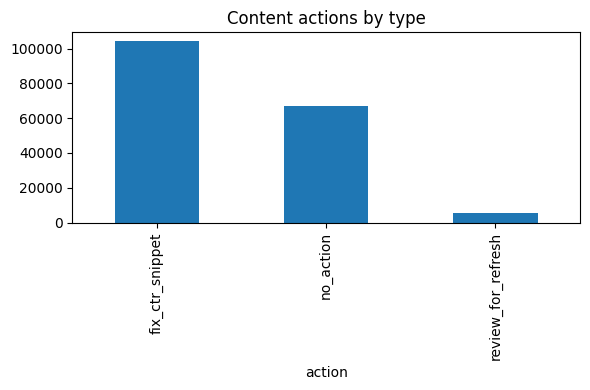

Exported: work/outputs/action_playbook_queue.csv (gitignored, regenerated)
Exported: work/outputs/w07_metrics.json (commit this)
Exported: work/figures/action_counts.png (commit this)


In [5]:
import os
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

playbook_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(monitoring_metrics, f, indent=2)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
playbook_queue["action"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Content actions by type")
plt.tight_layout()
plt.savefig("work/figures/action_counts.png", dpi=150)
plt.show()

print("Exported: work/outputs/action_playbook_queue.csv (gitignored, regenerated)")
print("Exported: work/outputs/w07_metrics.json (commit this)")
print("Exported: work/figures/action_counts.png (commit this)")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.